# PCA Experiments
Here we have tried to improve our PCA implementation by adding preprocessing steps.
## Imports

In [1]:
# Streamline imports and data loading via p3_module
import os
import numpy as np
from p3_module import set_seed, load_split, fit_pca_v2, pca_kmeans_predict_v2, extract_cell_features, best_flip, plot_confusion
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score, accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Set data dir and seed
DATA_DIR = r"../data/cells"
SEED = 42
set_seed(SEED)

# Load splits
X_train, y_train = load_split(DATA_DIR, "train")
X_dev, y_dev     = load_split(DATA_DIR, "dev")
X_test, y_test   = load_split(DATA_DIR, "test")
print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


## PCA sweep
Sweep explained variance over various PCA dimensions

For report: "Before clustering, we analyze how many principal components are required to explain a sufficient fraction of the variance in the raw pixel space."

In [2]:
# PCA Experiments
components = [2, 5, 10, 15, 20, 50]
explained_variances = []

for m in components:
    pca, X_train_pca = fit_pca_v2(X_train, n_components=m, standardize=False)
    e_vr = np.sum(pca.explained_variance_ratio_)
    explained_variances.append(e_vr)
    print(f"Components: {m}, Explained Variance Ratio: {e_vr:.4f}")

Components: 2, Explained Variance Ratio: 0.6184
Components: 5, Explained Variance Ratio: 0.8016
Components: 10, Explained Variance Ratio: 0.9039
Components: 15, Explained Variance Ratio: 0.9420
Components: 20, Explained Variance Ratio: 0.9582
Components: 50, Explained Variance Ratio: 0.9886


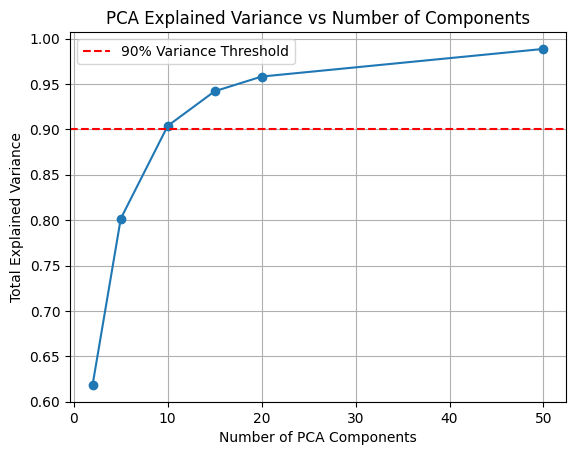

In [3]:
# Plot Explained Variance Ratio vs Number of Components
plt.figure
plt.plot(components, explained_variances, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.legend()
plt.xlabel('Number of PCA Components')
plt.ylabel('Total Explained Variance')
plt.title('PCA Explained Variance vs Number of Components')
plt.grid()
plt.show()

For report: "Around 10 principal components are required to explain 90% of the variance, indicating a high-dimensional structure in the raw pixel space."

In [4]:
results = []

for m in components:
    print(f"\n=== PCA + KMeans, m={m} ===")

    # Fit PCA on train
    pca, X_train_pca = fit_pca_v2(X_train, n_components=m, standardize=False)

    # Fit k-means
    kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=20)
    kmeans.fit(X_train_pca)

    # Predict on dev
    y_dev_pred = pca_kmeans_predict_v2(X_dev, pca, kmeans, invert_labels=True)

    # Compute metrics
    ari = adjusted_rand_score(y_dev, y_dev_pred)
    nmi = normalized_mutual_info_score(y_dev, y_dev_pred)
    f1  = f1_score(y_dev, y_dev_pred)
    acc = accuracy_score(y_dev, y_dev_pred)

    results.append((m, ari, nmi, f1, acc))
    print(f"ARI={ari:.4f}, NMI={nmi:.4f}, F1={f1:.4f}, Acc={acc:.4f}")



=== PCA + KMeans, m=2 ===
ARI=0.0000, NMI=0.0000, F1=0.0000, Acc=0.7306

=== PCA + KMeans, m=5 ===
ARI=0.0000, NMI=0.0000, F1=0.0000, Acc=0.7306

=== PCA + KMeans, m=10 ===
ARI=0.0000, NMI=0.0000, F1=0.4245, Acc=0.2694

=== PCA + KMeans, m=15 ===
ARI=0.0000, NMI=0.0000, F1=0.0000, Acc=0.7306

=== PCA + KMeans, m=20 ===
ARI=0.0000, NMI=0.0000, F1=0.0000, Acc=0.7306

=== PCA + KMeans, m=50 ===
ARI=0.0000, NMI=0.0000, F1=0.0000, Acc=0.7306


For report: "Despite capturing most of the variance, clustering performance remains poor across all dimensions. This suggest that dominant pixel variance directions are not alligned with live/dead differentiation.

I think we can use 2/3 components because it's better for visualization and it fails the same :)

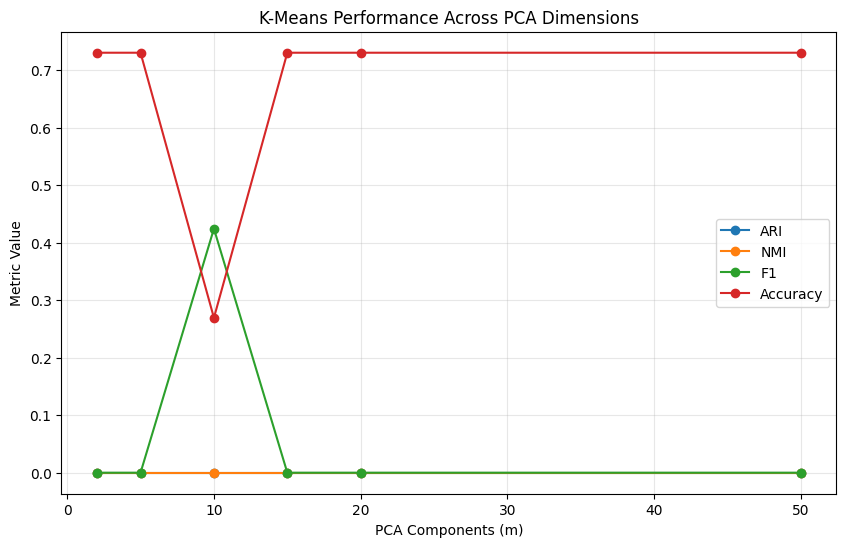

In [5]:
results = np.array(results)
ms = results[:,0]
aris = results[:,1]
nmis = results[:,2]
f1s  = results[:,3]
accs = results[:,4]

plt.figure(figsize=(10,6))
plt.plot(ms, aris, marker='o', label='ARI')
plt.plot(ms, nmis, marker='o', label='NMI')
plt.plot(ms, f1s, marker='o', label='F1')
plt.plot(ms, accs, marker='o', label='Accuracy')

plt.xlabel("PCA Components (m)")
plt.ylabel("Metric Value")
plt.title("K-Means Performance Across PCA Dimensions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Feature engineering
Dead and live cells have a lot of similarities so we try some manual enineered features to use for more "classic" PCA.

For report: "Visual inspection of the dataset suggests, that live/dead cells differ mainly in their internal intensity structure rather than in shape overall. In particualr live cells ofen have a brighter central region surrounded by a darker ring.

Therefore, we design a set of hand-crafted features whichwe then use for PCA instead of raw pixels.

In [6]:
# Extract features
F_train = extract_cell_features(X_train) # See p3_module for features
F_dev   = extract_cell_features(X_dev)

# Standardize
scaler = StandardScaler()
F_train_s = scaler.fit_transform(F_train)
F_dev_s   = scaler.transform(F_dev)

# PCA + KMeans
pca = PCA(n_components=3, random_state=42)
Z_train = pca.fit_transform(F_train_s)
Z_dev   = pca.transform(F_dev_s)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
kmeans.fit(Z_train)

dev_labels = kmeans.predict(Z_dev)
dev_labels = best_flip(y_dev, dev_labels)

print("ARI", adjusted_rand_score(y_dev, dev_labels))
print("NMI", normalized_mutual_info_score(y_dev, dev_labels))
print("F1 ", f1_score(y_dev, dev_labels))
print("Acc", accuracy_score(y_dev, dev_labels))


ARI 0.1991582566428074
NMI 0.28947149694279334
F1  0.6580645161290323
Acc 0.7253886010362695


In [7]:
print(confusion_matrix(y_dev, dev_labels))
print("Balanced Acc:", balanced_accuracy_score(y_dev, dev_labels))
print(classification_report(y_dev, dev_labels, digits=3))


[[89 52]
 [ 1 51]]
Balanced Acc: 0.805987452264048
              precision    recall  f1-score   support

           0      0.989     0.631     0.771       141
           1      0.495     0.981     0.658        52

    accuracy                          0.725       193
   macro avg      0.742     0.806     0.714       193
weighted avg      0.856     0.725     0.740       193



Checking a small grid to find optimal parameters of features

In [8]:
from itertools import product

param_grid = { #chose based on manual tuning and image inspection
    "n_components": [2, 3, 4, 5],
    "center_r": [2.5, 3.0, 3.5],
    "ring_r1": [3.5, 4.0, 4.5],
    "ring_r2": [7.0, 8.0, 9.0],
    "dark_thr": [0.25, 0.30, 0.35],
}

results = []

for (n_comp, cr, r1, r2, dthr) in product(
    param_grid["n_components"],
    param_grid["center_r"],
    param_grid["ring_r1"],
    param_grid["ring_r2"],
    param_grid["dark_thr"],
):
    # Feature extraction
    F_train = extract_cell_features(
        X_train,
        center_r=cr,
        ring_r1=r1,
        ring_r2=r2,
        dark_thr=dthr,
    )
    F_dev = extract_cell_features(
        X_dev,
        center_r=cr,
        ring_r1=r1,
        ring_r2=r2,
        dark_thr=dthr,
    )

    # Standardize
    scaler = StandardScaler()
    F_train_s = scaler.fit_transform(F_train)
    F_dev_s = scaler.transform(F_dev)

    # PCA
    pca = PCA(n_components=n_comp, random_state=SEED)
    Z_train = pca.fit_transform(F_train_s)
    Z_dev = pca.transform(F_dev_s)

    # KMeans
    kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=50)
    kmeans.fit(Z_train)

    preds = kmeans.predict(Z_dev)
    preds = best_flip(y_dev, preds)

    # Metrics
    f1 = f1_score(y_dev, preds)
    bal_acc = balanced_accuracy_score(y_dev, preds)

    results.append({
        "n_components": n_comp,
        "center_r": cr,
        "ring_r1": r1,
        "ring_r2": r2,
        "dark_thr": dthr,
        "f1": f1,
        "balanced_acc": bal_acc,
    })

# Sort by F1 - more informative for imbalanced classes
results = sorted(results, key=lambda x: x["f1"], reverse=True)

# Show top 5
for r in results[:5]:
    print(r)


{'n_components': 3, 'center_r': 2.5, 'ring_r1': 4.0, 'ring_r2': 7.0, 'dark_thr': 0.3, 'f1': 0.6754966887417219, 'balanced_acc': 0.8201718494271686}
{'n_components': 3, 'center_r': 2.5, 'ring_r1': 4.5, 'ring_r2': 7.0, 'dark_thr': 0.3, 'f1': 0.6710526315789473, 'balanced_acc': 0.8166257501363885}
{'n_components': 2, 'center_r': 2.5, 'ring_r1': 4.5, 'ring_r2': 7.0, 'dark_thr': 0.3, 'f1': 0.6666666666666666, 'balanced_acc': 0.8130796508456083}
{'n_components': 3, 'center_r': 2.5, 'ring_r1': 3.5, 'ring_r2': 8.0, 'dark_thr': 0.3, 'f1': 0.6666666666666666, 'balanced_acc': 0.8130796508456083}
{'n_components': 3, 'center_r': 2.5, 'ring_r1': 4.0, 'ring_r2': 8.0, 'dark_thr': 0.25, 'f1': 0.6666666666666666, 'balanced_acc': 0.8130796508456083}


Checking whether looping overhead is significant (it is, therefore feature extraction time can be reduced significantly with proper optimization)

UPDATE: extract_cell_features optimized

In [24]:
# sanity check: pure Python loop time
import time
x = np.random.rand(32,32)
_t0 = time.time()
for _ in range(1000):
    for i in range(32):
        for j in range(32):
            _ = x[i,j] * 2
print("Python loop time:", time.time() - _t0)


Python loop time: 0.14002323150634766


Checking which features contribute the most to the variance, PCs

In [ ]:
feature_names = [
    "gmean","gstd","cmean","rmean","c_minus_r","c_over_r",
    "radial_std","edge_energy","lap_var","dark_frac", "center_p90","peak_over_ring"
]

F_train = extract_cell_features(X_train)   # unscaled
vars_ = F_train.var(axis=0)

for name, v in sorted(zip(feature_names, vars_), key=lambda t: -t[1]):
    print(f"{name:12s} var={v:.6g}")

F_train = extract_cell_features(X_train)
scaler = StandardScaler()
F_train_s = scaler.fit_transform(F_train)

pca = PCA(n_components=min(10, F_train_s.shape[1]), random_state=42)
pca.fit(F_train_s)

print("Explained var ratio per PC:", np.round(pca.explained_variance_ratio_, 3))

for j in range(pca.n_components_):
    load = pca.components_[j]  # shape (n_features,)
    idx = np.argsort(np.abs(load))[::-1]
    top = idx[:3]
    print(f"\nPC{j+1} ({pca.explained_variance_ratio_[j]:.3f}):")
    for k in top:
        print(f"  {feature_names[k]:12s} loading={load[k]:+.3f}")


c_over_r     var=0.69576
cmean        var=0.0555499
c_minus_r    var=0.0540756
dark_frac    var=0.0314971
rmean        var=0.0272685
gmean        var=0.0101574
radial_std   var=0.00444852
gstd         var=0.00309788
edge_energy  var=0.00117561
lap_var      var=9.07928e-06
Explained var ratio per PC: [0.512 0.237 0.127 0.05  0.035 0.016 0.014 0.006 0.003 0.   ]

PC1 (0.512):
  c_minus_r    loading=+0.393
  radial_std   loading=+0.388
  edge_energy  loading=+0.385

PC2 (0.237):
  rmean        loading=+0.541
  gmean        loading=+0.498
  cmean        loading=+0.430

PC3 (0.127):
  lap_var      loading=+0.661
  cmean        loading=-0.380
  c_minus_r    loading=-0.359

PC4 (0.050):
  lap_var      loading=+0.630
  gstd         loading=-0.416
  radial_std   loading=-0.403

PC5 (0.035):
  rmean        loading=+0.504
  dark_frac    loading=+0.473
  gmean        loading=-0.444

PC6 (0.016):
  radial_std   loading=+0.674
  edge_energy  loading=-0.668
  c_over_r     loading=+0.197

PC7 (0.014):

### Sanity check on multiple seeds for robustness

In [90]:
seeds = [0,1,2,3,4,5,6,7,8,9]
f1s, aris, nmis, accs = [], [], [], []
for s in seeds:
    kmeans = KMeans(n_clusters=2, random_state=s, n_init=50).fit(Z_train)
    pred = best_flip(y_dev, kmeans.predict(Z_dev))
    f1s.append(f1_score(y_dev, pred))
    aris.append(adjusted_rand_score(y_dev, pred))
    nmis.append(normalized_mutual_info_score(y_dev, pred))
    accs.append(accuracy_score(y_dev, pred))

print("F1 mean±std:", np.mean(f1s), np.std(f1s))


F1 mean±std: 0.6322580645161289 1.1102230246251565e-16
